# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [1]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [3]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [5]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [6]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [7]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [9]:
# Mostrar los datos originales
print("Valores originales de sex:")
print(data['sex'].head())

# Mostrar los valores codificados con LabelEncoder
print("\nValores de sex con LabelEncoder:")
print(data[['sex', 'sex_label']].head())

# Mostrar los valores codificados con OneHotEncoder
print("\nValores de embarked con One-Hot Encoding:")
print(data[['embarked', 'embarked_C', 'embarked_Q', 'embarked_S']].head())

Valores originales de sex:
0      male
1    female
2    female
3    female
4      male
Name: sex, dtype: str

Valores de sex con LabelEncoder:
      sex  sex_label
0    male          1
1  female          0
2  female          0
3  female          0
4    male          1

Valores de embarked con One-Hot Encoding:
  embarked  embarked_C  embarked_Q  embarked_S
0        S       False       False        True
1        C        True       False       False
2        S       False       False        True
3        S       False       False        True
4        S       False       False        True


LabelEnconder convierte cada categoría en un número y One-Hot Encoding crea una columna por cada categoría

### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

<Axes: xlabel='categoria', ylabel='frecuencia'>

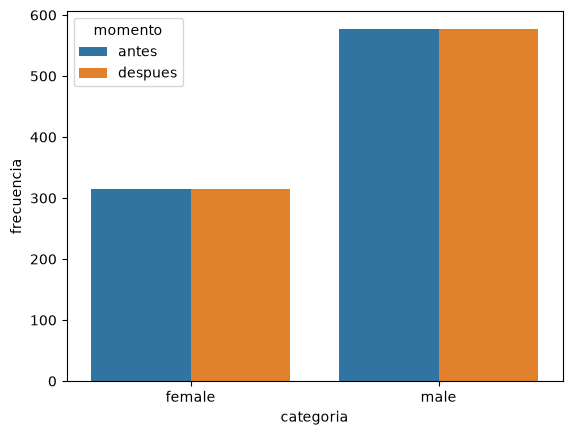

In [15]:
# Obtener las frecuencias antes de la codificación
frecuencias_antes = data['sex'].value_counts()

# Obtener las frecuencias después de la codificación
frecuencias_despues = data['sex_label'].value_counts()

# Crear un DataFrame para comparar
comparacion = pd.DataFrame({
    'categoria': ['female', 'male'],
    'antes': [
        frecuencias_antes['female'],
        frecuencias_antes['male']
    ],
    'despues': [
        frecuencias_despues[0],
        frecuencias_despues[1]
    ]
})

# Convertir el DataFrame a formato adecuado para Seaborn
comparacion = comparacion.melt(
    id_vars='categoria',
    var_name='momento',
    value_name='frecuencia'
)

# Crear gráfica
sns.barplot(
    data=comparacion,
    x='categoria',
    y='frecuencia',
    hue='momento'
)

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [16]:
# Codificar la columna class con OneHotEncoder
onehot_encoder = OneHotEncoder(sparse_output=False)

class_codificado = onehot_encoder.fit_transform(data[['class']])

# Convertir el resultado a DataFrame
class_codificado = pd.DataFrame(
    class_codificado,
    columns=onehot_encoder.get_feature_names_out(['class'])
)

# Mostrar las primeras filas
print(class_codificado.head())

   class_First  class_Second  class_Third
0          0.0           0.0          1.0
1          1.0           0.0          0.0
2          0.0           0.0          1.0
3          1.0           0.0          0.0
4          0.0           0.0          1.0


Si se utilizara LabelEnconder el modelo lo haria en un tipo orden que no nos dejaría claro la codificación, mientras que con OneHotEncoder se crean columnas independientes por lo que es sencilo de interpretar

### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

In [17]:
# Codificar sex con LabelEncoder
label_encoder = LabelEncoder()
sex_label = label_encoder.fit_transform(data[['sex']].values.ravel())

# Codificar class con OneHotEncoder
onehot_encoder = OneHotEncoder(sparse_output=False)
class_onehot = onehot_encoder.fit_transform(data[['class']])

# Mostrar algunos resultados
print("LabelEncoder para sex:")
print(sex_label[:5])

print("\nOneHotEncoder para class:")
print(class_onehot[:5])

LabelEncoder para sex:
[1 0 0 0 1]

OneHotEncoder para class:
[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


Utilizaría OneHotEncoder ya que en las variables categoricas que no tienen un orden natural sirve de mejor manera. OneHotEncoder lo que hace es que convierte cada categoría en una columna independiente y evita crear una relacion númerica artificial entre categorías lo cual evitaría errores para limpiar datos para un modelo de aprendizaje automatico